# Proyecto

Minería de Datos \
CC5205-2 - Primavera 2025 \
Integrantes: 
- Sebastián Cadena
- Juan Balboa
- Benjamín Fuentes Rodrigo
- Camila Rojas
- Matías Méndez


## Dataset.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


from sklearn.feature_selection import SelectKBest, mutual_info_classif

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

Dataset utilizado: **114000 Spotify Songs**. \
Obtenido de: https://www.kaggle.com/datasets/priyamchoksi/spotify-dataset-114k-songs.

In [2]:
# Se leen y muestran los datos.
spotifySongDS = pd.read_csv('dataset_clusters_10.csv') # modificado -> 'dataset.csv', 'dataset_with_clusters.csv', 
spotifySongDS.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,4
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,1
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,1
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1


In [3]:
# Se muestran las columnas del dataset a partir de un ejemplo.
ej = spotifySongDS.iloc[10]
print(ej)

Unnamed: 0                              10
track_id            4mzP5mHkRvGxdhdGdAH7EJ
artists                       Zack Tabudlo
album_name                         Episode
track_name            Give Me Your Forever
popularity                              74
duration_ms                         244800
explicit                             False
danceability                         0.627
energy                               0.363
key                                      8
loudness                            -8.127
mode                                     1
speechiness                         0.0291
acousticness                         0.279
instrumentalness                       0.0
liveness                            0.0928
valence                              0.301
tempo                               99.905
time_signature                           4
track_genre                       acoustic
cluster                                  9
Name: 10, dtype: object


## Clasificador de géneros en canciones.

In [4]:
# Caso 1: Por grupos elegidos al azar.

# Se crea una copia del dataset.
#classificationData = spotifySongDS.copy()

# Se elige el número de clases.
#classes = list(range(0, 100, 10)) # list(range(0, 100))
#topgenre = classificationData.groupby("track_genre").count().index[classes]
#print(f"Clases utilizadas: {topgenre}")

# Se filtran los datos según las clases elegidas.
#classificationData = classificationData[classificationData["track_genre"].isin(topgenre)]

In [5]:
# Caso 2: Por clustering.

# Se crea una copia del dataset.
classificationData = spotifySongDS.copy()

# Se elige el número de clases.
#topgenre = classificationData.groupby("cluster").count().index
topgenre = classificationData.groupby("cluster")["track_genre"].agg(lambda x: x.value_counts().idxmax())
print(f"Clases utilizadas: {topgenre}")

# Se filtran los datos según las clases elegidas.
classificationData = classificationData[classificationData["track_genre"].isin(topgenre)]

Clases utilizadas: cluster
0            pagode
1           romance
2        honky-tonk
3    minimal-techno
4         reggaeton
5         hardstyle
6           j-dance
7            comedy
8           new-age
9         metalcore
Name: track_genre, dtype: object


In [6]:
# Se muestran las columnas disponibles.
classificationData.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre', 'cluster'],
      dtype='object')

In [7]:
# Características utilizadas.
c = ['popularity', 'duration_ms', 'explicit', 'danceability', "energy",
     "key", "loudness", "mode", "speechiness", "acousticness", 
     'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

X_clasification = classificationData[c]

# Clase.
y_clasification_str = np.squeeze(classificationData[["track_genre"]]) # Modificado -> "track_genre"
le = LabelEncoder() # target encoder.
le.fit(y_clasification_str)
y_clasification = le.transform(y_clasification_str)
# le.inverse_transform()

In [8]:
# Se escala los datos.
scalerC = StandardScaler()
X_clasification_scaled = scalerC.fit_transform(X_clasification)

In [9]:
# Se separan los conjuntos X e y en conjuntos de entrenamiento, validación y prueba.
X_train, X_vt, y_train, y_vt = train_test_split(X_clasification_scaled, y_clasification, test_size = 0.4, random_state = 0, stratify = y_clasification)
X_val, X_test, y_val, y_test = train_test_split(X_vt, y_vt, test_size = 0.5, random_state = 0)

In [10]:
# Se elijen los mejores parámetros para clasificar con SelectKbest.
kBestModel = SelectKBest(mutual_info_classif, k = 11)
kBestModel.fit(X_train, y_train)
X_train_k = kBestModel.transform(X_train)
X_val_k = kBestModel.transform(X_val)

kBestModel.get_feature_names_out(input_features = c)

array(['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo'], dtype=object)

In [11]:
# Se concatena el conjunto de entrenamiento con el de validación.
X = np.concatenate((X_train_k, X_val_k))
Y = np.concatenate((y_train, y_val))

### Random Forest

In [12]:
# Se crea el modelo de Random Forest.
rf = RandomForestClassifier(random_state = 0)

# Se crea el diccionario de hiperparámetros.
hiperparam_Random_Forest = {"max_depth": [None, 5, 15, 20, 25, 35], "n_estimators": [300, 400, 450, 500, 600]}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 0)
#cv = StratifiedShuffleSplit(n_splits = 1, test_size = 0.25, random_state = 0)

In [ ]:
# Creamos la grilla para evaluar los hiperparámetros
grid_Random_Forest = GridSearchCV(rf, hiperparam_Random_Forest, cv = cv, verbose = 5)

# Entrenamos cada caso con el conjunto de entrenamiento y validación
grid_Random_Forest.fit(X, Y)

# Hiperparámetro del mejor clasificador Random Forest, con su puntación
print("\nLos parámetros del mejor clasificador Random Forest, según la grilla son:")
print(grid_Random_Forest.best_params_)
print("\nCon una puntación de:", grid_Random_Forest.best_score_)

In [13]:
# Se crea el modelo definitivo :O
rfFinal = RandomForestClassifier(max_depth = 15, n_estimators = 300, random_state = 0) 
rfFinal.fit(X_train_k, y_train)

# Casos buenos con 10 clases normales:
# 20, 450, con 11 parámetros.
# 15, 300, 11 parámetros.

rf_val_pred = rfFinal.predict(X_val_k)

              precision    recall  f1-score   support

           0      0.988     0.852     0.915       196
           1      0.843     0.883     0.862       188
           2      0.939     0.948     0.944       194
           3      0.768     0.798     0.783       203
           4      0.918     0.932     0.925       192
           5      0.919     0.955     0.937       202
           6      0.927     0.922     0.925       206
           7      0.900     0.975     0.936       202
           8      0.908     0.874     0.890       214
           9      0.984     0.931     0.957       203

    accuracy                          0.907      2000
   macro avg      0.909     0.907     0.907      2000
weighted avg      0.909     0.907     0.907      2000



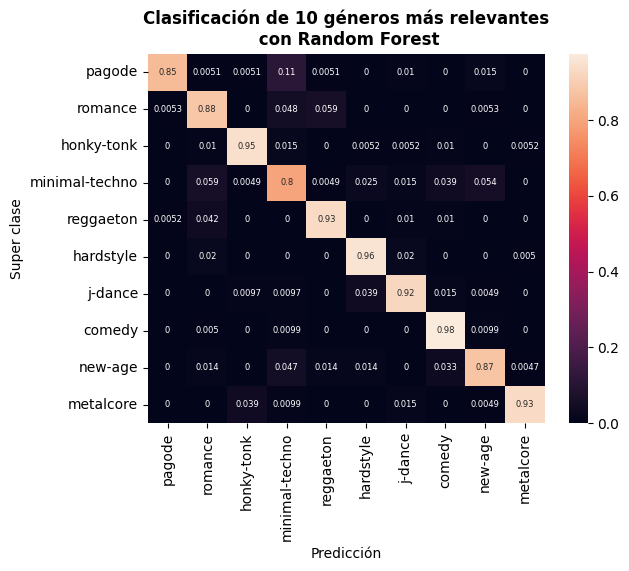

In [30]:
print(classification_report(y_val, rf_val_pred, digits=3))

sns.heatmap(confusion_matrix(y_val, rf_val_pred, normalize = "true"), annot = True, fmt = ".2g", annot_kws={"size": 6}, xticklabels = list(topgenre), yticklabels = list(topgenre))

plt.ylabel('Super clase')
plt.xlabel('Predicción')
plt.title('Clasificación de 10 géneros más relevantes\n con Random Forest', fontweight = 'bold')

plt.show()


### Modelo XGBoost

In [25]:
# Se crea el modelo.
xgb = XGBClassifier(objective="multi:softmax", num_class = 10, tree_method = "hist")

# Se crea el diccionario de hiperparámetros.
hiperparam_XGB = {
    "n_estimators": [200, 500],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.1, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 0)
#cv = StratifiedShuffleSplit(n_splits = 1, test_size = 0.25, random_state = 0)

In [ ]:
# Creamos la grilla para evaluar los hiperparámetros
grid_XGB = GridSearchCV(xgb, hiperparam_XGB, cv = cv, verbose = 5)

# Entrenamos cada caso con el conjunto de entrenamiento y validación
grid_XGB.fit(X, Y)

# Hiperparámetro del mejor clasificador XGB, con su puntación
print("\nLos parámetros del mejor clasificador XGB, según la grilla son:")
print(grid_XGB.best_params_)
print("\nCon una puntación de:", grid_XGB.best_score_)

In [26]:
# Se crea el modelo definitivo :O
xgbFinal = XGBClassifier(objective="multi:softmax", num_class = 10, tree_method = "hist",
                         colsample_bytree = 0.8, learning_rate = 0.1, max_depth = 6, n_estimators = 200, subsample = 0.8)
xgbFinal.fit(X_train_k, y_train)

xgb_val_pred = xgbFinal.predict(X_val_k)

              precision    recall  f1-score   support

           0      0.946     0.893     0.919       196
           1      0.884     0.888     0.886       188
           2      0.969     0.954     0.961       194
           3      0.836     0.828     0.832       203
           4      0.925     0.964     0.944       192
           5      0.938     0.970     0.954       202
           6      0.925     0.961     0.943       206
           7      0.947     0.975     0.961       202
           8      0.937     0.902     0.919       214
           9      0.975     0.946     0.960       203

    accuracy                          0.928      2000
   macro avg      0.928     0.928     0.928      2000
weighted avg      0.928     0.928     0.928      2000



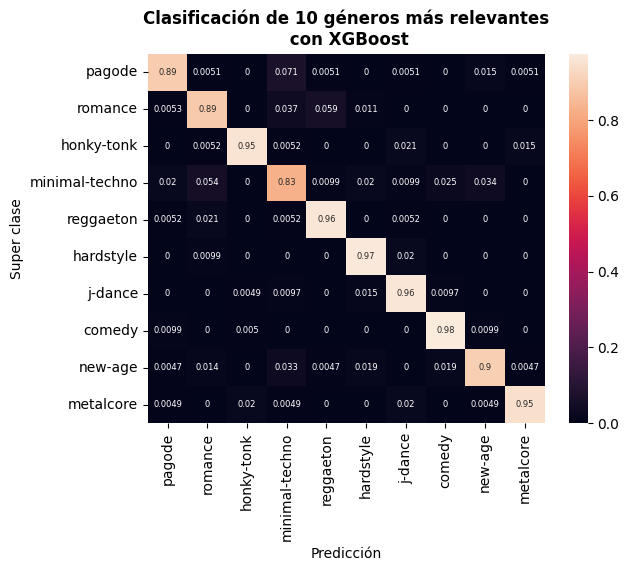

In [31]:
print(classification_report(y_val, xgb_val_pred, digits=3))

sns.heatmap(confusion_matrix(y_val, xgb_val_pred, normalize = "true"), annot = True, fmt = ".2g", annot_kws={"size": 6}, xticklabels = list(topgenre), yticklabels = list(topgenre))

plt.ylabel('Super clase')
plt.xlabel('Predicción')
plt.title('Clasificación de 10 géneros más relevantes\n con XGBoost', fontweight = 'bold')

plt.show()
